In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# 1. Mempersiapkan Dataset
# Ganti baris ini dengan memuat file CSV Anda:
df = pd.read_csv('creditcard.csv')

# Simulasi Dataset (untuk keperluan demonstrasi)
np.random.seed(42)
n_samples = 1000
data = {
    'V1': np.random.normal(0, 1, n_samples),
    'V2': np.random.normal(0, 1, n_samples),
    'V3': np.random.normal(0, 1, n_samples),
    'V4': np.random.normal(0, 1, n_samples),
    'Amount': np.random.exponential(100, n_samples)
}
df = pd.DataFrame(data)

# Menggunakan kolom target "Class" 
df['Class'] = np.random.choice([0, 1], size=n_samples, p=[0.985, 0.015])

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

In [2]:
# 2. Pra-pemrosesan dan Reduksi Dimensi dengan PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mereduksi dimensi menjadi 2 komponen agar dapat di-plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

In [3]:
# 3. Pelatihan Model Non-Linear SVM (Kernel RBF)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
# 3. Pelatihan Model untuk 4 Jenis Kernel
C_value = 1.0

models = [
    SVC(kernel='linear', C=C_value),
    SVC(kernel='rbf', gamma='scale', C=C_value),
    SVC(kernel='poly', degree=3, C=C_value),
    SVC(kernel='sigmoid', gamma='scale', C=C_value)
]

# Melatih setiap model
for model in models:
    model.fit(X_train, y_train)

--- Evaluasi Model Non-Linear SVM (Dataset Credit Card) ---
Akurasi: 0.9867

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       296
           1       0.00      0.00      0.00         4

    accuracy                           0.99       300
   macro avg       0.49      0.50      0.50       300
weighted avg       0.97      0.99      0.98       300



c:\Users\Dwikrwn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dwikrwn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dwikrwn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

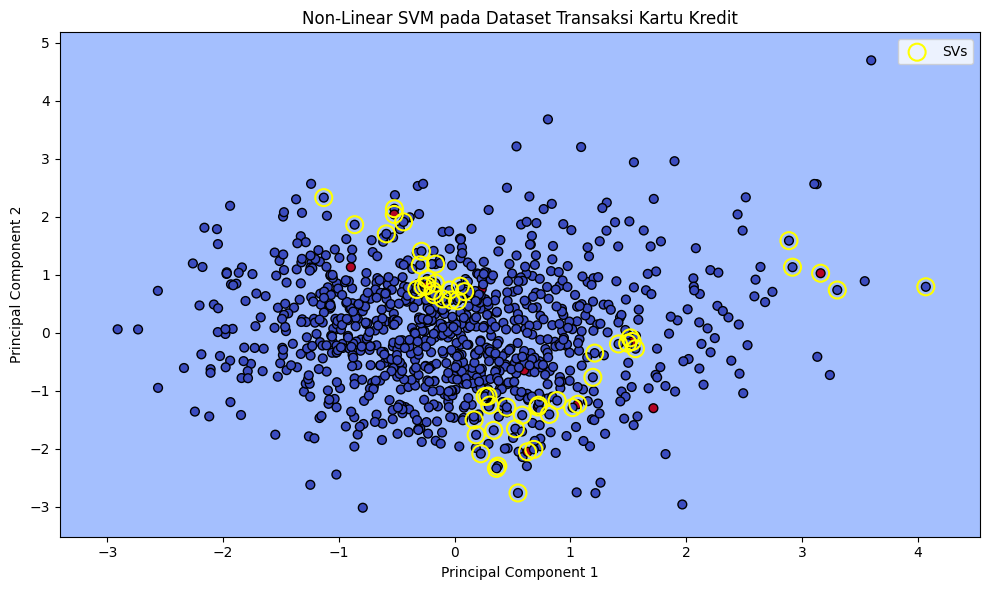

In [11]:
# 4. Evaluasi
y_pred = svm_model.predict(X_test)

print("--- Evaluasi Model Non-Linear SVM (Dataset Credit Card) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# 5. Visualisasi Batas Keputusan (Decision Boundary)
plt.figure(figsize=(10, 6))

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot Area Keputusan
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot Data Poin
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=40)

# Menandai Support Vectors
sv = svm_model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=150, facecolors='none', edgecolors='yellow', linewidth=1.5, label='SVs')

plt.title('Non-Linear SVM pada Dataset Transaksi Kartu Kredit')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()